In [1]:
from tensorflow import keras
import os
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
import librosa
import random

from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, precision_recall_curve

from transformers import Resampler, BandPassFilter, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, NoiseAdder, WaveletDenoiser

from config import N_MELS, SAMPLING_RATE, N_FFT, HOP_LENGTH, SEED

In [2]:
random.seed(SEED)

In [3]:
def show_precision_recall_curve(y_true, y_proba, punto_corte=0.5):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)

    plt.plot(thr, rec[:-1], label='recall')
    plt.plot(thr, prec[:-1], label='precision')
    plt.xlabel('Punto de corte')
    plt.vlines(punto_corte, 0, 1, colors='red', linestyles='dashed', label='corte')
    plt.grid()
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.legend()
    plt.show()

def show_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Matriz de Confusión');

def load_image_dataset_pil(img_dir, to_gray=True, flatten=False, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if to_gray:
            img = img.convert('L')  # convierte a escala de grises (1 canal)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img, dtype=np.float32)
        
        if flatten:
            img = img.flatten()
        
        X.append(img)
        y.append(row['label'])
    
    return np.array(X), np.array(y)

def load_image_dataset(img_dir, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img)

        X.append(img)
        y.append(row['label'])

    return np.array(X), np.array(y)

def load_images(img_dir, target_size=None):
    images = []
    for filename in os.listdir(img_dir):
        if filename.endswith('.png'):
            path = os.path.join(img_dir, filename)
            img = Image.open(path)
            
            if target_size:
                img = img.resize(target_size, Image.BICUBIC)
            
            img = np.array(img)
            images.append(img)
    return np.array(images)

def plot_melspectrogram(y, sr, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax)
    return img


# Modelos Datos crudos

Datos originales sin filtro ni ruido

In [5]:
dataset = 'crudos'

## Random Forest 

### Mel Espectrogramas

In [6]:
test_data = np.load(f'./dataset/ventanas_procesadas/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [7]:
melspec_rf = joblib.load(f'./modelos_clasicos/modelos/ventanas/{dataset}/melspec_rf.pkl')

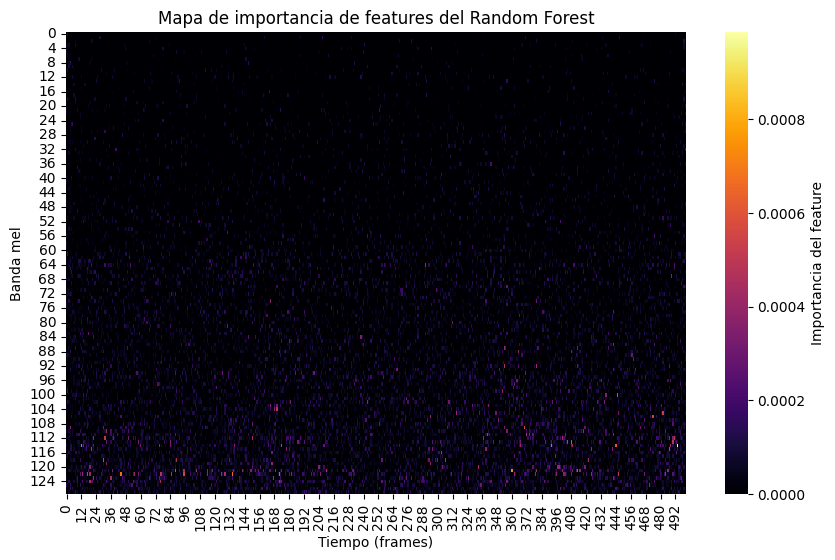

In [8]:
importances = melspec_rf.feature_importances_

n_mels = N_MELS
n_frames = importances.shape[0] // n_mels

importance_img = importances.reshape((n_mels, n_frames))
importance_img = np.flipud(importance_img)

plt.figure(figsize=(10, 6))
sns.heatmap(
    importance_img,
    cmap='inferno',
    cbar_kws={'label': 'Importancia del feature'},
)
plt.xlabel("Tiempo (frames)")
plt.ylabel("Banda mel")
plt.title("Mapa de importancia de features del Random Forest");

In [9]:
y_pred = melspec_rf.predict(X_test)
y_pred_proba = melspec_rf.predict_proba(X_test)[:, 1]

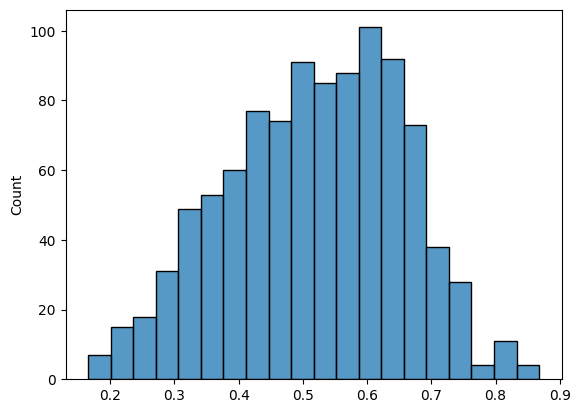

In [10]:
sns.histplot(y_pred_proba, bins=20);

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.59      0.62       484
           1       0.65      0.71      0.68       515

    accuracy                           0.65       999
   macro avg       0.65      0.65      0.65       999
weighted avg       0.65      0.65      0.65       999



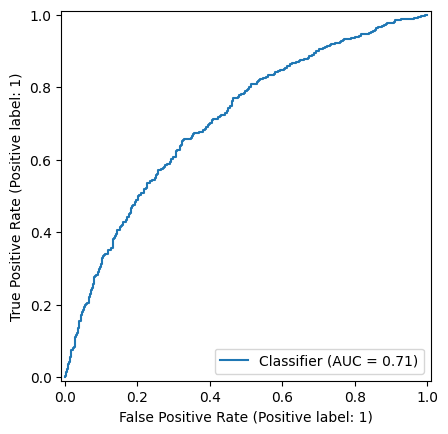

In [12]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

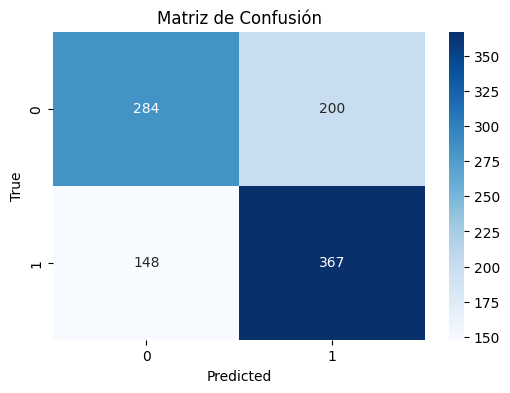

In [13]:
show_confusion_matrix(y_test, y_pred)

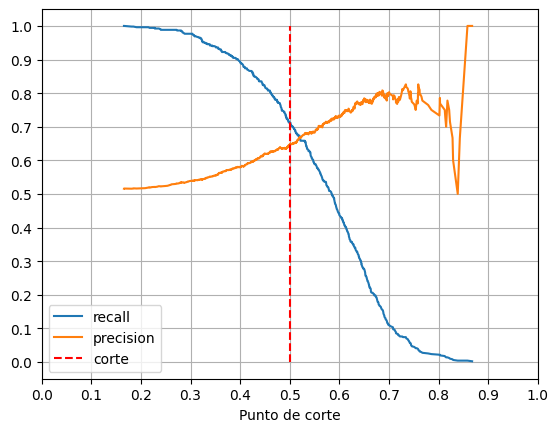

In [14]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

### Atributos de audio

In [15]:
test_data = np.load(f'./dataset/ventanas_procesadas/{dataset}/test_features.npz')
X_test = test_data['X']
y_test = test_data['y']

In [16]:
feat_rf = joblib.load(f'./modelos_clasicos/modelos/ventanas/{dataset}/features_rf.pkl')

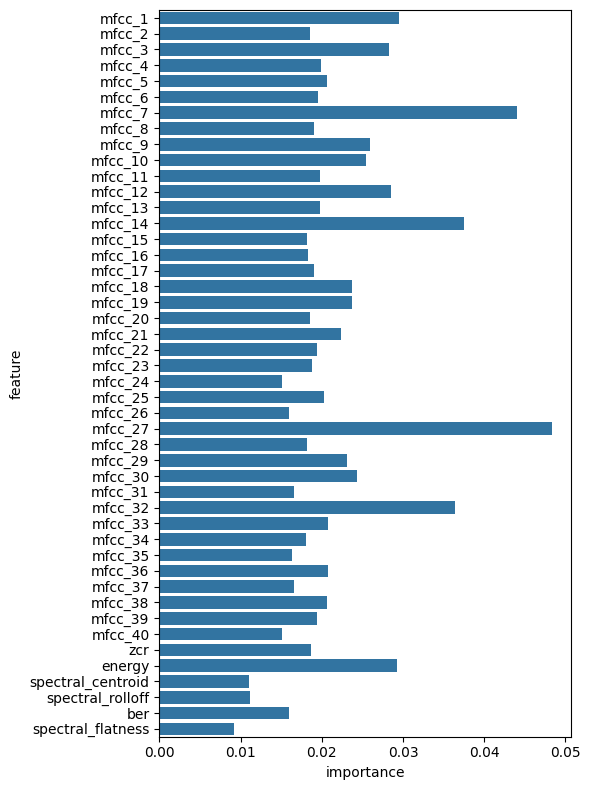

In [17]:
importances = feat_rf.feature_importances_
columns = ['mfcc_' + str(i) for i in range(1, 41)] + ['zcr', 'energy', 'spectral_centroid', 'spectral_rolloff', 'ber', 'spectral_flatness']

importance_df = pd.DataFrame({
    'feature': columns,
    'importance': importances
})
plt.figure(figsize=(6, 8))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.tight_layout();

In [18]:
y_pred = feat_rf.predict(X_test)
y_pred_proba = feat_rf.predict_proba(X_test)[:, 1]

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.75      0.76       484
           1       0.77      0.80      0.79       515

    accuracy                           0.77       999
   macro avg       0.77      0.77      0.77       999
weighted avg       0.77      0.77      0.77       999



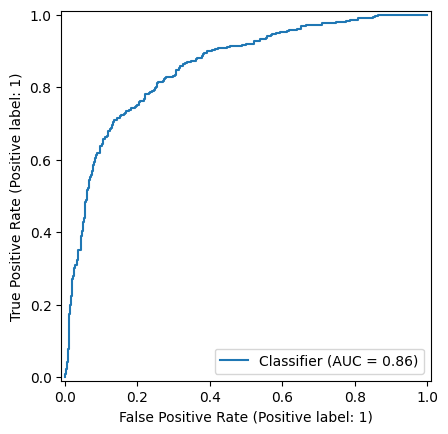

In [20]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

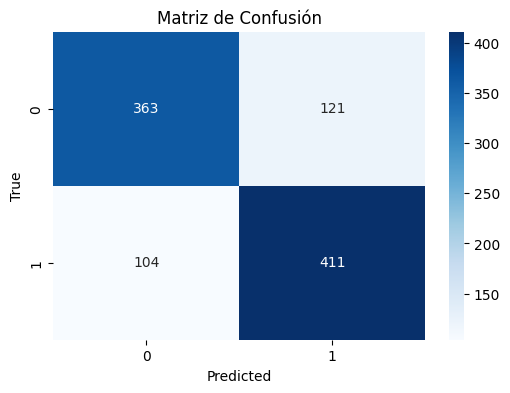

In [21]:
show_confusion_matrix(y_test, y_pred)

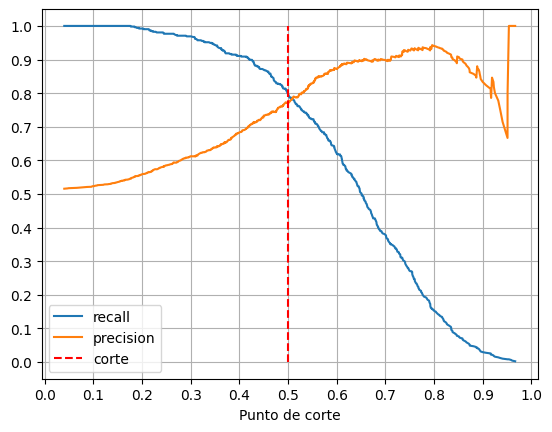

In [22]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

## CNN

### Imagenes de Mel Espectrogramas

In [23]:
test_dir = f'./dataset/ventanas_procesadas/{dataset}/imgs/test'

X_test, y_test = load_image_dataset(test_dir, target_size=(501, 128))

In [24]:
cnn_img = keras.models.load_model(f'./neural_network/modelos/ventanas_{dataset}.keras')

In [25]:
y_pred_proba = cnn_img.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 763ms/step


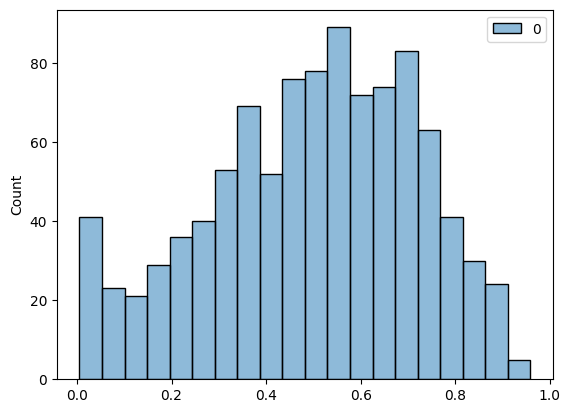

In [26]:
sns.histplot(y_pred_proba, bins=20);

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.63      0.65       484
           1       0.67      0.70      0.68       515

    accuracy                           0.67       999
   macro avg       0.67      0.66      0.66       999
weighted avg       0.67      0.67      0.67       999



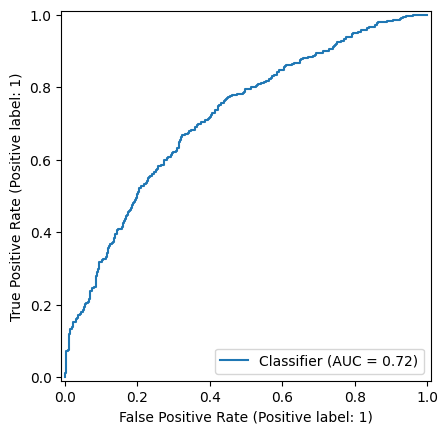

In [28]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

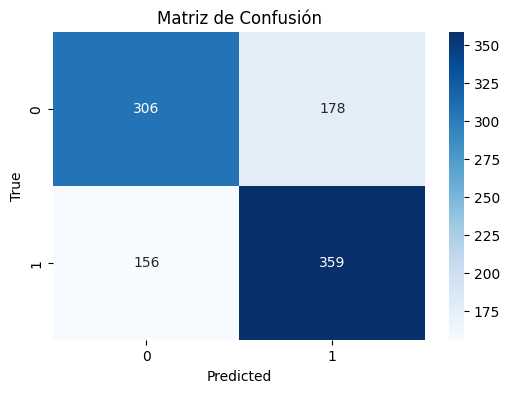

In [29]:
show_confusion_matrix(y_test, y_pred)

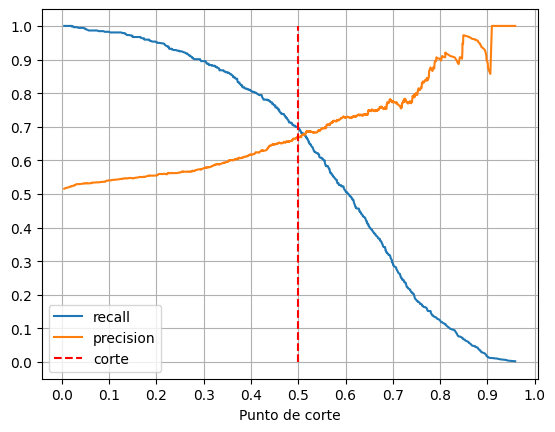

In [30]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

### Mel Espectrograma (Matriz)

In [32]:
test_data = np.load(f'./dataset/ventanas_procesadas/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [33]:
X_test = X_test.reshape(-1, 128, 501, 1)
X_test = np.repeat(X_test, 3, axis=-1)

In [34]:
cnn_melspec = keras.models.load_model(f'./neural_network/modelos/ventanas_{dataset}_melspec.keras')

In [35]:
y_pred_proba = cnn_melspec.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 752ms/step


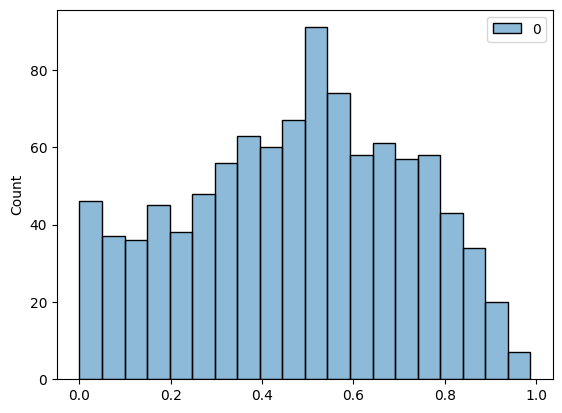

In [36]:
sns.histplot(y_pred_proba, bins=20);

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.70      0.68       484
           1       0.70      0.67      0.69       515

    accuracy                           0.68       999
   macro avg       0.68      0.69      0.68       999
weighted avg       0.69      0.68      0.68       999



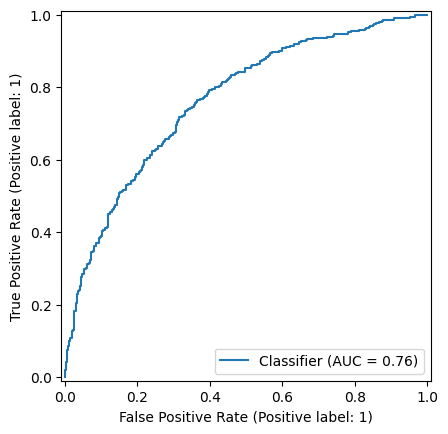

In [38]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

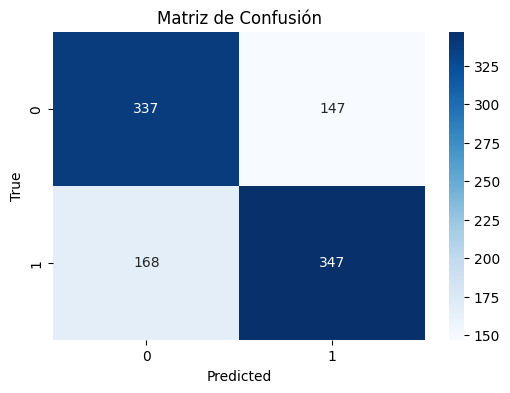

In [39]:
show_confusion_matrix(y_test, y_pred)

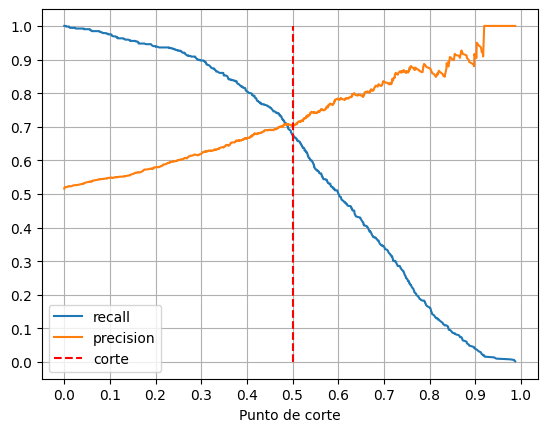

In [40]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

# Modelos Datos Adaptados

In [41]:
dataset = 'aug_sin_proc'

## Random Forest 

### Mel Espectrogramas

In [42]:
test_data = np.load(f'./dataset/ventanas_procesadas/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [43]:
melspec_rf = joblib.load(f'./modelos_clasicos/modelos/ventanas/{dataset}/melspec_rf.pkl')

FileNotFoundError: [Errno 2] No such file or directory: './modelos_clasicos/modelos/ventanas/aug_sin_proc/melspec_rf.pkl'

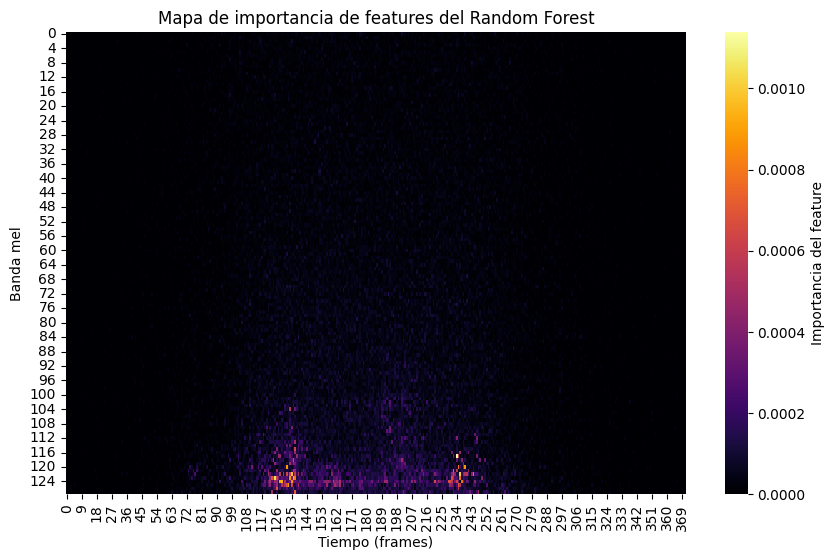

In [20]:
importances = melspec_rf.feature_importances_

n_mels = N_MELS
n_frames = importances.shape[0] // n_mels

importance_img = importances.reshape((n_mels, n_frames))
importance_img = np.flipud(importance_img)

plt.figure(figsize=(10, 6))
sns.heatmap(
    importance_img,
    cmap='inferno',
    cbar_kws={'label': 'Importancia del feature'},
)
plt.xlabel("Tiempo (frames)")
plt.ylabel("Banda mel")
plt.title("Mapa de importancia de features del Random Forest");

In [21]:
y_pred = melspec_rf.predict(X_test)
y_pred_proba = melspec_rf.predict_proba(X_test)[:, 1]

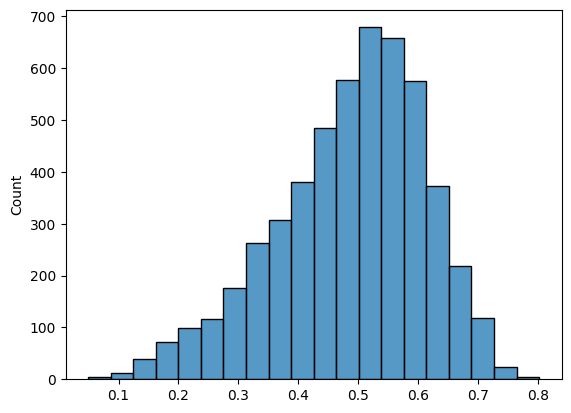

In [22]:
sns.histplot(y_pred_proba, bins=20);

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.61      0.62      2652
           1       0.61      0.64      0.63      2532

    accuracy                           0.62      5184
   macro avg       0.62      0.62      0.62      5184
weighted avg       0.63      0.62      0.62      5184



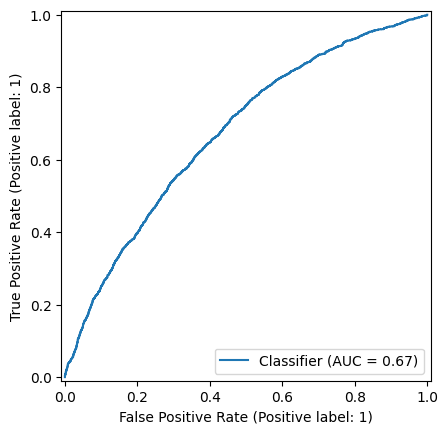

In [28]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

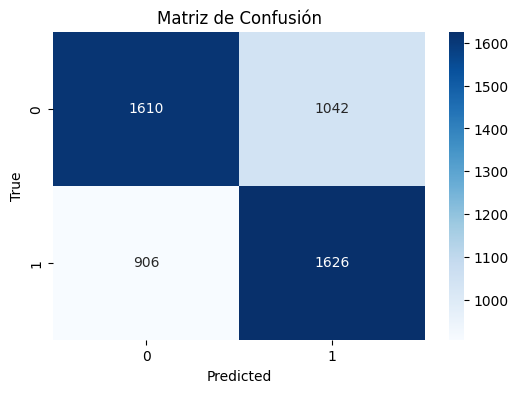

In [24]:
show_confusion_matrix(y_test, y_pred)

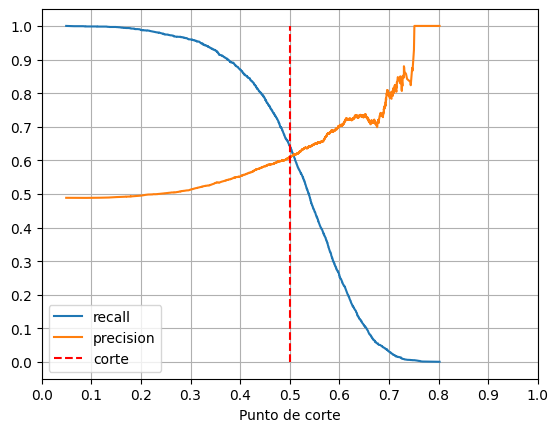

In [25]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

### Atributos de audio

In [44]:
test_data = np.load(f'./dataset/ventanas_procesadas/{dataset}/test_features.npz')
X_test = test_data['X']
y_test = test_data['y']

In [45]:
feat_rf = joblib.load(f'./modelos_clasicos/modelos/ventanas/{dataset}/features_rf.pkl')

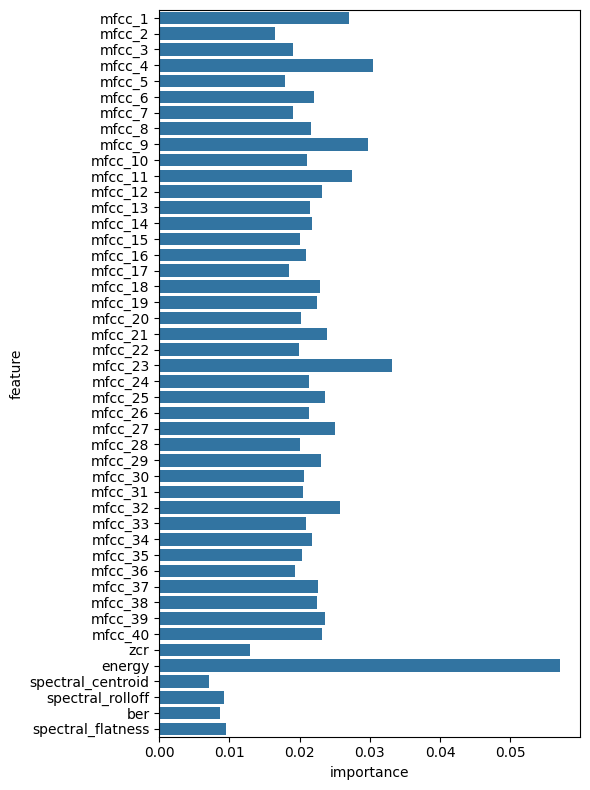

In [46]:
importances = feat_rf.feature_importances_
columns = ['mfcc_' + str(i) for i in range(1, 41)] + ['zcr', 'energy', 'spectral_centroid', 'spectral_rolloff', 'ber', 'spectral_flatness']

importance_df = pd.DataFrame({
    'feature': columns,
    'importance': importances
})
plt.figure(figsize=(6, 8))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.tight_layout();

In [47]:
y_pred = feat_rf.predict(X_test)
y_pred_proba = feat_rf.predict_proba(X_test)[:, 1]

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.55      0.58      1936
           1       0.61      0.67      0.64      2060

    accuracy                           0.61      3996
   macro avg       0.61      0.61      0.61      3996
weighted avg       0.61      0.61      0.61      3996



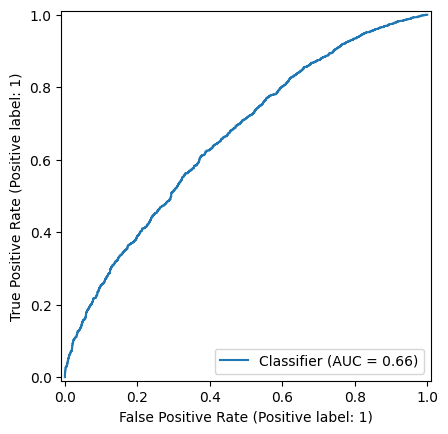

In [49]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

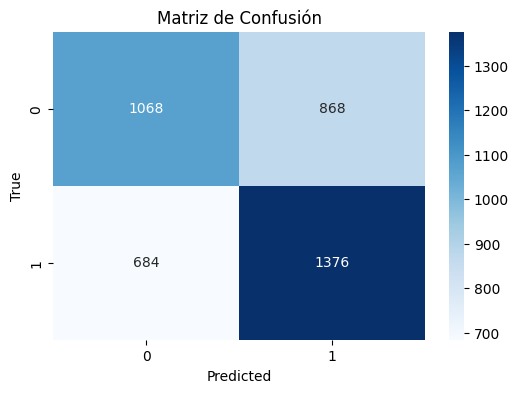

In [50]:
show_confusion_matrix(y_test, y_pred)

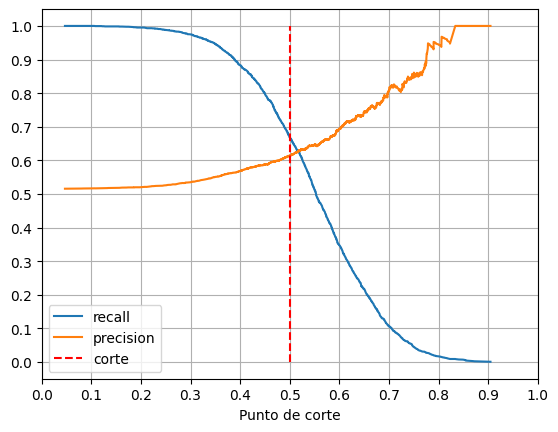

In [51]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

## CNN

### Imagenes de Mel Espectrogramas

In [52]:
test_dir = f'./dataset/ventanas_procesadas/{dataset}/imgs/test'

X_test, y_test = load_image_dataset(test_dir, target_size=(501, 128))

In [53]:
cnn_img = keras.models.load_model(f'./neural_network/modelos/ventanas_{dataset}.keras')

In [54]:
y_pred_proba = cnn_img.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 99s 777ms/step


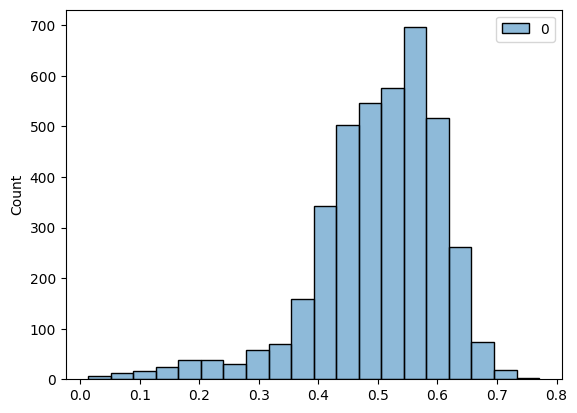

In [55]:
sns.histplot(y_pred_proba, bins=20);

In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.54      0.56      1936
           1       0.60      0.64      0.62      2060

    accuracy                           0.59      3996
   macro avg       0.59      0.59      0.59      3996
weighted avg       0.59      0.59      0.59      3996



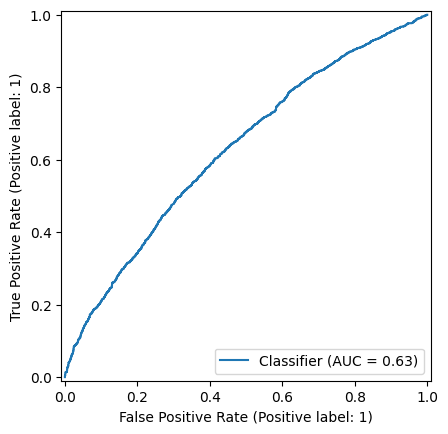

In [57]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

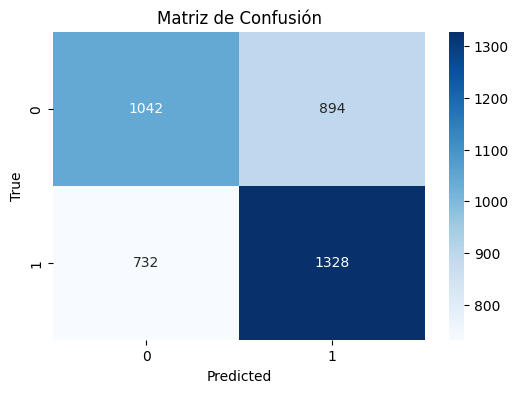

In [58]:
show_confusion_matrix(y_test, y_pred)

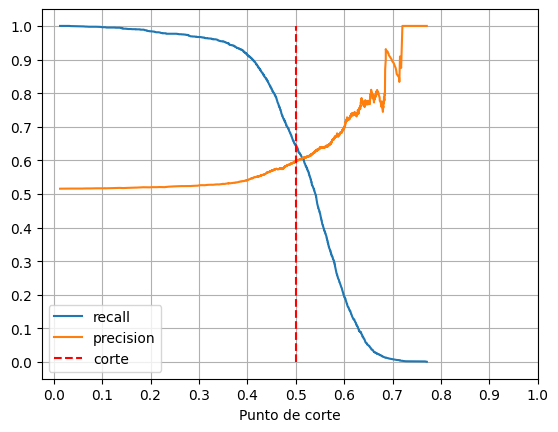

In [59]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

### Mel Espectrograma (Matriz)

In [60]:
test_data = np.load(f'./dataset/ventanas_procesadas/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [61]:
X_test = X_test.reshape(-1, 128, 501, 1)
X_test = np.repeat(X_test, 3, axis=-1)

In [62]:
cnn_melspec = keras.models.load_model(f'./neural_network/modelos/ventanas_{dataset}_melspec.keras')

In [63]:
y_pred_proba = cnn_melspec.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 102s 804ms/step


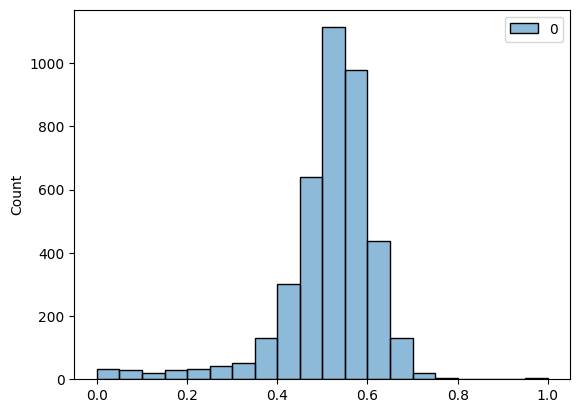

In [64]:
sns.histplot(y_pred_proba, bins=20);

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.40      0.48      1936
           1       0.57      0.74      0.64      2060

    accuracy                           0.58      3996
   macro avg       0.58      0.57      0.56      3996
weighted avg       0.58      0.58      0.56      3996



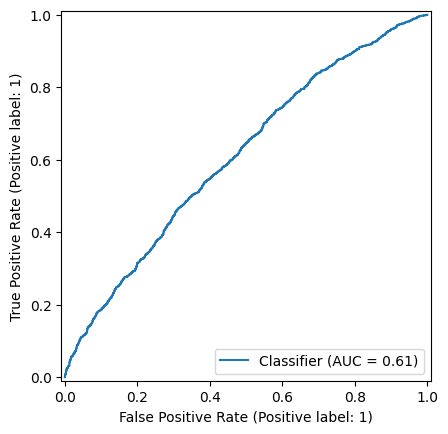

In [66]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

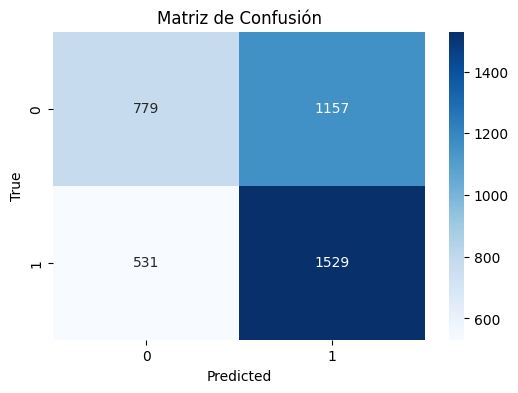

In [67]:
show_confusion_matrix(y_test, y_pred)

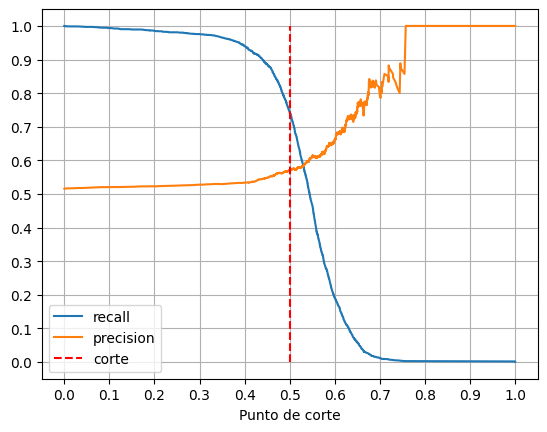

In [68]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)